# 🧠 Natural Language Processing (NLP) Basics

## Objectives
In this notebook, you will learn:
- NLP fundamentals
- Text preprocessing techniques
- NLTK library usage
- Word embeddings and similarity
- Text classification (Sentiment & Topic Modeling)
- Sequence tagging (Named Entity Recognition)

Dataset:
➡️ Product Reviews (Google Review–style text)

## 📘 What is Natural Language Processing (NLP)?

NLP enables machines to understand, interpret, and generate human language.

### Real-world NLP Applications:
- Google reviews & sentiment analysis
- Chatbots & virtual assistants
- Spam detection
- Search engines
- Resume parsing

## 🔄 NLP Processing Pipeline

1. Raw Text
2. Text Cleaning
3. Tokenization
4. Stopword Removal
5. Stemming / Lemmatization
6. Feature Extraction (Embeddings)
7. Modeling (Classification / Tagging)

##Import Libraries

In [ ]:
import nltk
import re
import string
import numpy as np
import pandas as pd

In [ ]:
# Download required NLTK resources
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('averaged_perceptron_tagger')
nltk.download('maxent_ne_chunker')
nltk.download('words')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger.zip.
[nltk_data] Downloading package maxent_ne_chunker to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping chunkers/maxent_ne_chunker.zip.
[nltk_data] Downloading package words to /root/nltk_data...
[nltk_data]   Unzipping corpora/words.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

## 📝 Sample Product Reviews (Google Review Style)

In [ ]:
reviews = [
    "The phone quality is amazing and battery life is excellent!",
    "Worst customer service ever. Totally disappointed.",
    "The camera is decent but performance is slow.",
    "Absolutely love this product. Highly recommended!",
    "Not worth the price. Poor build quality."
]

## 🧹 Text Cleaning

We remove:
- Punctuation
- Numbers
- Special characters
- Convert text to lowercase

In [ ]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r'\d+', '', text)
    text = text.translate(str.maketrans('', '', string.punctuation))
    return text

cleaned_reviews = [clean_text(r) for r in reviews]
cleaned_reviews

['the phone quality is amazing and battery life is excellent',
 'worst customer service ever totally disappointed',
 'the camera is decent but performance is slow',
 'absolutely love this product highly recommended',
 'not worth the price poor build quality']

##TEXT PROCESSING

## 🔤 Tokenization

Tokenization splits text into individual words (tokens).

In [ ]:
from nltk.tokenize import word_tokenize

tokens = [word_tokenize(r) for r in cleaned_reviews]
tokens

[['the',
  'phone',
  'quality',
  'is',
  'amazing',
  'and',
  'battery',
  'life',
  'is',
  'excellent'],
 ['worst', 'customer', 'service', 'ever', 'totally', 'disappointed'],
 ['the', 'camera', 'is', 'decent', 'but', 'performance', 'is', 'slow'],
 ['absolutely', 'love', 'this', 'product', 'highly', 'recommended'],
 ['not', 'worth', 'the', 'price', 'poor', 'build', 'quality']]

## 🚫 Stop Words

Stop words are common words (is, the, and) that add little meaning.

In [ ]:
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

filtered_tokens = [
    [word for word in review if word not in stop_words]
    for review in tokens
]

filtered_tokens

[['phone', 'quality', 'amazing', 'battery', 'life', 'excellent'],
 ['worst', 'customer', 'service', 'ever', 'totally', 'disappointed'],
 ['camera', 'decent', 'performance', 'slow'],
 ['absolutely', 'love', 'product', 'highly', 'recommended'],
 ['worth', 'price', 'poor', 'build', 'quality']]

## 🌱 Stemming vs Lemmatization

- **Stemming**: Cuts words to root form (playing → play)
- **Lemmatization**: Converts words to dictionary form (better accuracy)

We will demonstrate both.

In [ ]:
from nltk.stem import PorterStemmer, WordNetLemmatizer

stemmer = PorterStemmer()
lemmatizer = WordNetLemmatizer()

stemmed = [[stemmer.stem(w) for w in review] for review in filtered_tokens]
lemmatized = [[lemmatizer.lemmatize(w) for w in review] for review in filtered_tokens]

stemmed, lemmatized

([['phone', 'qualiti', 'amaz', 'batteri', 'life', 'excel'],
  ['worst', 'custom', 'servic', 'ever', 'total', 'disappoint'],
  ['camera', 'decent', 'perform', 'slow'],
  ['absolut', 'love', 'product', 'highli', 'recommend'],
  ['worth', 'price', 'poor', 'build', 'qualiti']],
 [['phone', 'quality', 'amazing', 'battery', 'life', 'excellent'],
  ['worst', 'customer', 'service', 'ever', 'totally', 'disappointed'],
  ['camera', 'decent', 'performance', 'slow'],
  ['absolutely', 'love', 'product', 'highly', 'recommended'],
  ['worth', 'price', 'poor', 'build', 'quality']])

## 📚 Corpus

A **corpus** is a large collection of processed text documents.

In [ ]:
corpus = [" ".join(review) for review in lemmatized]
corpus

['phone quality amazing battery life excellent',
 'worst customer service ever totally disappointed',
 'camera decent performance slow',
 'absolutely love product highly recommended',
 'worth price poor build quality']

## 🧠 Word Embeddings

Word embeddings represent words as numeric vectors capturing semantic meaning.

### Popular Embeddings:
- Word2Vec
- GloVe
- FastText

### Word2Vec (Concept)

Learns word relationships based on context.

To work with pre-trained models in Gensim, you can use the gensim.downloader module to load models directly. For example, to load the "glove-twitter-25" model:



In [ ]:
pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 55.6 MB/s eta 0:00:00


In [ ]:
import gensim.downloader as api
model = api.load('glove-twitter-25')

[==================================================] 100.0% 104.8/104.8MB downloaded


In [ ]:
from gensim.models import Word2Vec

w2v_model = Word2Vec(tokens, vector_size=50, window=5, min_count=1)
w2v_model.wv['quality']

array([-0.01725349,  0.00734418,  0.01037191,  0.0114824 ,  0.01493014,
       -0.01234323,  0.00220183,  0.01208695, -0.00568648, -0.01235045,
       -0.00082676, -0.01673297, -0.01121325,  0.01420478,  0.00671753,
        0.014462  ,  0.01361185,  0.01506889, -0.00757884, -0.00113104,
        0.00470476, -0.00903623,  0.01678933, -0.01971154,  0.01354095,
        0.00584021, -0.00987915,  0.00878951, -0.00347805,  0.0134326 ,
        0.01994164, -0.00871951, -0.00118956, -0.01139921,  0.00771079,
        0.00556911,  0.01377325,  0.01221512,  0.01908148,  0.01854628,
        0.01579551, -0.01398623, -0.01830865, -0.00070628, -0.00620383,
        0.01578211,  0.01187461, -0.0030922 ,  0.00302978,  0.00357718],
      dtype=float32)

## 📐 Cosine Similarity

Measures similarity between two word vectors.

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

cosine_similarity(
    [w2v_model.wv['quality']],
    [w2v_model.wv['product']]
)

array([[0.12123733]], dtype=float32)

## 🌐 GloVe & FastText (Conceptual)

- **GloVe**: Uses global word co-occurrence statistics
- **FastText**: Uses character-level embeddings (handles misspellings)

(Used in large-scale NLP systems like Facebook, Google Search)

## 🧩 Text Classification

Classifying text into categories:
- Sentiment Analysis
- Topic Modeling

In [ ]:
from nltk.sentiment import SentimentIntensityAnalyzer
nltk.download('vader_lexicon')

sia = SentimentIntensityAnalyzer()

for review in reviews:
    print(review)
    print(sia.polarity_scores(review))
    print("----")

The phone quality is amazing and battery life is excellent!
{'neg': 0.0, 'neu': 0.507, 'pos': 0.493, 'compound': 0.8313}
----
Worst customer service ever. Totally disappointed.
{'neg': 0.652, 'neu': 0.348, 'pos': 0.0, 'compound': -0.8173}
----
The camera is decent but performance is slow.
{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound': 0.0}
----
Absolutely love this product. Highly recommended!
{'neg': 0.0, 'neu': 0.368, 'pos': 0.632, 'compound': 0.7832}
----
Not worth the price. Poor build quality.
{'neg': 0.488, 'neu': 0.512, 'pos': 0.0, 'compound': -0.5812}
----


[nltk_data] Downloading package vader_lexicon to /root/nltk_data...


## 🗂 Topic Modeling

Discovers hidden topics in documents.
Popular methods:
- LDA (Latent Dirichlet Allocation)
- NMF

## 🏷 Sequence Tagging

Assigns labels to each word in a sentence.

Examples:
- POS Tagging
- Named Entity Recognition (NER)

In [ ]:
import nltk
nltk.download('averaged_perceptron_tagger_eng')

[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.


True

In [ ]:
sentence = word_tokenize("Apple is looking at buying a startup in India")
nltk.pos_tag(sentence)

[('Apple', 'NNP'),
 ('is', 'VBZ'),
 ('looking', 'VBG'),
 ('at', 'IN'),
 ('buying', 'VBG'),
 ('a', 'DT'),
 ('startup', 'NN'),
 ('in', 'IN'),
 ('India', 'NNP')]

Named Entity Recognition Code

In [ ]:
import nltk
nltk.download('maxent_ne_chunker_tab')

[nltk_data] Downloading package maxent_ne_chunker_tab to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping chunkers/maxent_ne_chunker_tab.zip.


True

In [ ]:
!pip install svgling

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.1/67.1 kB 5.3 MB/s eta 0:00:00


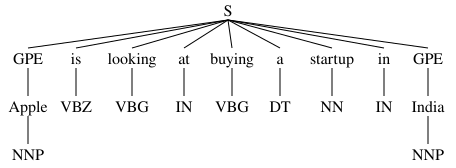

In [ ]:

from nltk import ne_chunk

ner_tree = ne_chunk(nltk.pos_tag(sentence))
ner_tree

## 🧠 Practice Exercises

1. Preprocess a custom Google review text using all NLP steps.
2. Train Word2Vec on a larger corpus.
3. Compare cosine similarity between positive vs negative words.
4. Perform NER on multiple customer feedback sentences.
5. Try FastText embeddings and compare results.

1. Preprocess a custom Google review text using all NLP steps

In [ ]:
reviews = [
    "The food was absolutely delicious and the staff were very friendly. Loved the ambiance!",
    "Very poor service. Had to wait 30 minutes and the food was cold when it arrived.",
    "Great location and good food, but the service was slow and a bit disappointing.",
    "Amazing experience! Clean environment, quick service, and tasty dishes. Highly recommended!",
    "Not worth the price. The taste was average and the place was too crowded and noisy."
]

In [ ]:
def preprocess_text(text):
  text = text.lower()
  text = re.sub(r'\d+','',text)
  text = text.translate(str.maketrans('','',string.punctuation))
  return text

cleaned_text = [preprocess_text(text) for text in reviews ]
cleaned_text

['the food was absolutely delicious and the staff were very friendly loved the ambiance',
 'very poor service had to wait  minutes and the food was cold when it arrived',
 'great location and good food but the service was slow and a bit disappointing',
 'amazing experience clean environment quick service and tasty dishes highly recommended',
 'not worth the price the taste was average and the place was too crowded and noisy']

In [ ]:
from nltk.tokenize import word_tokenize

tokens = [word_tokenize(text) for text in cleaned_text]
tokens

[['the',
  'food',
  'was',
  'absolutely',
  'delicious',
  'and',
  'the',
  'staff',
  'were',
  'very',
  'friendly',
  'loved',
  'the',
  'ambiance'],
 ['very',
  'poor',
  'service',
  'had',
  'to',
  'wait',
  'minutes',
  'and',
  'the',
  'food',
  'was',
  'cold',
  'when',
  'it',
  'arrived'],
 ['great',
  'location',
  'and',
  'good',
  'food',
  'but',
  'the',
  'service',
  'was',
  'slow',
  'and',
  'a',
  'bit',
  'disappointing'],
 ['amazing',
  'experience',
  'clean',
  'environment',
  'quick',
  'service',
  'and',
  'tasty',
  'dishes',
  'highly',
  'recommended'],
 ['not',
  'worth',
  'the',
  'price',
  'the',
  'taste',
  'was',
  'average',
  'and',
  'the',
  'place',
  'was',
  'too',
  'crowded',
  'and',
  'noisy']]

In [ ]:
from nltk.corpus import stopwords
stopwords = set(stopwords.words('english'))

stopwords = [[word for word in review if word not in stopwords] for review in tokens]
stopwords

[['food', 'absolutely', 'delicious', 'staff', 'friendly', 'loved', 'ambiance'],
 ['poor', 'service', 'wait', 'minutes', 'food', 'cold', 'arrived'],
 ['great',
  'location',
  'good',
  'food',
  'service',
  'slow',
  'bit',
  'disappointing'],
 ['amazing',
  'experience',
  'clean',
  'environment',
  'quick',
  'service',
  'tasty',
  'dishes',
  'highly',
  'recommended'],
 ['worth', 'price', 'taste', 'average', 'place', 'crowded', 'noisy']]

In [ ]:
from nltk.stem import PorterStemmer

stemming = PorterStemmer()

stemmed = [[stemming.stem(word) for word in review] for review in tokens]

stemmed


[['the',
  'food',
  'wa',
  'absolut',
  'delici',
  'and',
  'the',
  'staff',
  'were',
  'veri',
  'friendli',
  'love',
  'the',
  'ambianc'],
 ['veri',
  'poor',
  'servic',
  'had',
  'to',
  'wait',
  'minut',
  'and',
  'the',
  'food',
  'wa',
  'cold',
  'when',
  'it',
  'arriv'],
 ['great',
  'locat',
  'and',
  'good',
  'food',
  'but',
  'the',
  'servic',
  'wa',
  'slow',
  'and',
  'a',
  'bit',
  'disappoint'],
 ['amaz',
  'experi',
  'clean',
  'environ',
  'quick',
  'servic',
  'and',
  'tasti',
  'dish',
  'highli',
  'recommend'],
 ['not',
  'worth',
  'the',
  'price',
  'the',
  'tast',
  'wa',
  'averag',
  'and',
  'the',
  'place',
  'wa',
  'too',
  'crowd',
  'and',
  'noisi']]

In [ ]:
from nltk.stem import WordNetLemmatizer

lemmatization = WordNetLemmatizer()

lemmatized = [[lemmatization.lemmatize(word) for word in review] for review in tokens]

lemmatized

[['the',
  'food',
  'wa',
  'absolutely',
  'delicious',
  'and',
  'the',
  'staff',
  'were',
  'very',
  'friendly',
  'loved',
  'the',
  'ambiance'],
 ['very',
  'poor',
  'service',
  'had',
  'to',
  'wait',
  'minute',
  'and',
  'the',
  'food',
  'wa',
  'cold',
  'when',
  'it',
  'arrived'],
 ['great',
  'location',
  'and',
  'good',
  'food',
  'but',
  'the',
  'service',
  'wa',
  'slow',
  'and',
  'a',
  'bit',
  'disappointing'],
 ['amazing',
  'experience',
  'clean',
  'environment',
  'quick',
  'service',
  'and',
  'tasty',
  'dish',
  'highly',
  'recommended'],
 ['not',
  'worth',
  'the',
  'price',
  'the',
  'taste',
  'wa',
  'average',
  'and',
  'the',
  'place',
  'wa',
  'too',
  'crowded',
  'and',
  'noisy']]

In [ ]:
corpus = [' '.join(words) for words in lemmatized]
corpus

['the food wa absolutely delicious and the staff were very friendly loved the ambiance',
 'very poor service had to wait minute and the food wa cold when it arrived',
 'great location and good food but the service wa slow and a bit disappointing',
 'amazing experience clean environment quick service and tasty dish highly recommended',
 'not worth the price the taste wa average and the place wa too crowded and noisy']

2. Train Word2Vec on a larger corpus

In [ ]:
processed_corpus= corpus*200

processed_corpus

['the food wa absolutely delicious and the staff were very friendly loved the ambiance',
 'very poor service had to wait minute and the food wa cold when it arrived',
 'great location and good food but the service wa slow and a bit disappointing',
 'amazing experience clean environment quick service and tasty dish highly recommended',
 'not worth the price the taste wa average and the place wa too crowded and noisy',
 'the food wa absolutely delicious and the staff were very friendly loved the ambiance',
 'very poor service had to wait minute and the food wa cold when it arrived',
 'great location and good food but the service wa slow and a bit disappointing',
 'amazing experience clean environment quick service and tasty dish highly recommended',
 'not worth the price the taste wa average and the place wa too crowded and noisy',
 'the food wa absolutely delicious and the staff were very friendly loved the ambiance',
 'very poor service had to wait minute and the food wa cold when it a

In [ ]:
def preprocess_text(text):
  text = text.lower()
  text = re.sub(r'\d+','',text)
  text = text.translate(str.maketrans('','',string.punctuation))
  tokens = word_tokenize(text)
  return tokens

processed_corpus = [preprocess_text(text) for text in processed_corpus]
processed_corpus

[['the',
  'food',
  'wa',
  'absolutely',
  'delicious',
  'and',
  'the',
  'staff',
  'were',
  'very',
  'friendly',
  'loved',
  'the',
  'ambiance'],
 ['very',
  'poor',
  'service',
  'had',
  'to',
  'wait',
  'minute',
  'and',
  'the',
  'food',
  'wa',
  'cold',
  'when',
  'it',
  'arrived'],
 ['great',
  'location',
  'and',
  'good',
  'food',
  'but',
  'the',
  'service',
  'wa',
  'slow',
  'and',
  'a',
  'bit',
  'disappointing'],
 ['amazing',
  'experience',
  'clean',
  'environment',
  'quick',
  'service',
  'and',
  'tasty',
  'dish',
  'highly',
  'recommended'],
 ['not',
  'worth',
  'the',
  'price',
  'the',
  'taste',
  'wa',
  'average',
  'and',
  'the',
  'place',
  'wa',
  'too',
  'crowded',
  'and',
  'noisy'],
 ['the',
  'food',
  'wa',
  'absolutely',
  'delicious',
  'and',
  'the',
  'staff',
  'were',
  'very',
  'friendly',
  'loved',
  'the',
  'ambiance'],
 ['very',
  'poor',
  'service',
  'had',
  'to',
  'wait',
  'minute',
  'and',
  'the'

In [ ]:
model = Word2Vec(
    sentences=processed_corpus,
    vector_size=100,
    window=5,
    min_count=1,
    workers=4,
    sg=1
)
model

In [ ]:
print(model.wv['food'])

[-0.2873905   0.07967629 -0.39766243 -0.2509844   0.05612376 -0.0544766
  0.15104595  0.12394066 -0.05135269  0.04537078 -0.00912722 -0.03047167
  0.02935132  0.06796795 -0.12201799 -0.30783704  0.26160872 -0.02183034
  0.00895378 -0.0095128  -0.0437715  -0.10194468  0.34410816 -0.00393419
  0.18955757 -0.28189075  0.06899516  0.05580318 -0.39663187 -0.007722
  0.2937129  -0.01506675  0.08810031 -0.5344102   0.04598485  0.18669394
  0.05308193 -0.0395618   0.01674831 -0.01892771 -0.33180156 -0.05257874
 -0.08903921 -0.20158903  0.2020608  -0.12915407  0.20672688  0.00892066
  0.11774807  0.03120786  0.09420452  0.1077322  -0.05484696 -0.04131334
  0.09146506 -0.16751911  0.14990169 -0.00703181 -0.30792093 -0.09534871
  0.22268003 -0.2928541   0.09067983  0.03193362 -0.09447782  0.10884408
 -0.1598932   0.0260193  -0.2976494   0.3020475   0.17917676  0.05889447
  0.33338186  0.1860301   0.17076348 -0.10788722 -0.13784632  0.133582
 -0.02561095  0.00588562 -0.17307255 -0.14792277 -0.2583

In [ ]:
print(model.wv.most_similar('food'))

[('very', 0.8447397947311401), ('poor', 0.7852494716644287), ('to', 0.77700275182724), ('had', 0.7649335265159607), ('arrived', 0.7644731998443604), ('minute', 0.7623093724250793), ('wait', 0.7591238617897034), ('it', 0.7576764225959778), ('cold', 0.7563745379447937), ('when', 0.753442645072937)]


In [ ]:
print(f'{model.wv.similarity('food', 'service'):.4f}')

0.5637


In [ ]:
model.save("word2vec.model")
from gensim.models import Word2Vec
model = Word2Vec.load("word2vec.model")

3. Compare cosine similarity between positive vs negative words.

In [ ]:
print(model.wv.index_to_key)

['the', 'and', 'wa', 'service', 'food', 'very', 'noisy', 'crowded', 'too', 'place', 'average', 'taste', 'price', 'worth', 'not', 'recommended', 'highly', 'dish', 'tasty', 'quick', 'environment', 'clean', 'experience', 'amazing', 'disappointing', 'bit', 'a', 'slow', 'but', 'good', 'location', 'great', 'arrived', 'it', 'when', 'cold', 'minute', 'wait', 'to', 'had', 'poor', 'ambiance', 'loved', 'friendly', 'were', 'staff', 'delicious', 'absolutely']


In [ ]:
positive_words = ["good", "great", "amazing", "delicious", "tasty"]
negative_words = ["poor", "disappointing", "noisy", "crowded"]

In [ ]:

print("Positive vs Positive:")
for i in range(len(positive_words)):
    for j in range(i+1, len(positive_words)):
        w1, w2 = positive_words[i], positive_words[j]
        print(f"{w1} vs {w2}: {model.wv.similarity(w1, w2):.3f}")

Positive vs Positive:
good vs great: 0.996
good vs amazing: 0.402
good vs delicious: 0.351
good vs tasty: 0.405
great vs amazing: 0.426
great vs delicious: 0.360
great vs tasty: 0.428
amazing vs delicious: 0.194
amazing vs tasty: 0.999
delicious vs tasty: 0.200


In [ ]:
print("\nNegative vs Negative:")
for i in range(len(negative_words)):
    for j in range(i+1, len(negative_words)):
        w1, w2 = negative_words[i], negative_words[j]
        print(f"{w1} vs {w2}: {model.wv.similarity(w1, w2):.3f}")


Negative vs Negative:
poor vs disappointing: 0.357
poor vs noisy: 0.256
poor vs crowded: 0.258
disappointing vs noisy: 0.395
disappointing vs crowded: 0.376
noisy vs crowded: 0.998


In [ ]:
print("\nPositive vs Negative:")
for p in positive_words:
    for n in negative_words:
        print(f"{p} vs {n}: {model.wv.similarity(p, n):.3f}")


Positive vs Negative:
good vs poor: 0.360
good vs disappointing: 0.998
good vs noisy: 0.403
good vs crowded: 0.383
great vs poor: 0.388
great vs disappointing: 0.997
great vs noisy: 0.361
great vs crowded: 0.342
amazing vs poor: 0.375
amazing vs disappointing: 0.419
amazing vs noisy: 0.303
amazing vs crowded: 0.315
delicious vs poor: 0.483
delicious vs disappointing: 0.354
delicious vs noisy: 0.466
delicious vs crowded: 0.461
tasty vs poor: 0.377
tasty vs disappointing: 0.422
tasty vs noisy: 0.317
tasty vs crowded: 0.330


4. Perform NER on multiple customer feedback sentences

In [ ]:
sentences = [
    "I visited Domino's in Bangalore and loved the pizza.",
    "The service at McDonald's was disappointing last Sunday.",
    "Ordered from Amazon and got delivery in 2 days.",
    "Had dinner at Taj Hotel in Mumbai, amazing experience!",
    "Flipkart customer support in India is very helpful."
]

In [ ]:
from nltk import pos_tag, ne_chunk
for sentence in sentences:
    print("\nSentence:", sentence)
    tokens = word_tokenize(sentence)
    entities = ne_chunk(nltk.pos_tag(tokens))
    print(entities)


Sentence: I visited Domino's in Bangalore and loved the pizza.
(S
  I/PRP
  visited/VBD
  (PERSON Domino/NNP)
  's/POS
  in/IN
  (GPE Bangalore/NNP)
  and/CC
  loved/VBD
  the/DT
  pizza/NN
  ./.)

Sentence: The service at McDonald's was disappointing last Sunday.
(S
  The/DT
  service/NN
  at/IN
  (ORGANIZATION McDonald/NNP)
  's/POS
  was/VBD
  disappointing/VBG
  last/JJ
  Sunday/NNP
  ./.)

Sentence: Ordered from Amazon and got delivery in 2 days.
(S
  Ordered/VBN
  from/IN
  (GPE Amazon/NNP)
  and/CC
  got/VBD
  delivery/NN
  in/IN
  2/CD
  days/NNS
  ./.)

Sentence: Had dinner at Taj Hotel in Mumbai, amazing experience!
(S
  (GPE Had/NNP)
  dinner/NN
  at/IN
  (FACILITY Taj/NNP Hotel/NNP)
  in/IN
  (GPE Mumbai/NNP)
  ,/,
  amazing/VBG
  experience/NN
  !/.)

Sentence: Flipkart customer support in India is very helpful.
(S
  (GPE Flipkart/NNP)
  customer/NN
  support/NN
  in/IN
  (GPE India/NNP)
  is/VBZ
  very/RB
  helpful/JJ
  ./.)


5. Try FastText embeddings and compare results

In [ ]:
from gensim.models import FastText
from nltk.tokenize import word_tokenize

processed = [word_tokenize(text.lower()) for text in reviews]
processed = processed*200
ft_model = FastText(
    sentences=processed,
    vector_size=100,
    window=5,
    min_count=1,
    workers=4
)

In [ ]:
print("Word2Vec similarity:")
print(f"{model.wv.similarity('good', 'great'):.4f}")

print("\nFastText similarity:")
print(f"{ft_model.wv.similarity('good', 'great'):.4f}")

Word2Vec similarity:
0.9964

FastText similarity:
0.9975


In [ ]:
print("FastText handles unseen word:")
print(ft_model.wv['tastyy'])

FastText handles unseen word:
[-0.02350158  0.20732075  0.05498691 -0.01436308  0.02155123  0.15799743
  0.11604284  0.22216073  0.05946122 -0.00700034  0.13209644 -0.15027039
  0.0555643   0.28452662 -0.04090239 -0.05396913  0.07083575 -0.01623182
 -0.02951118 -0.12228264  0.0473898   0.02080573  0.14388269 -0.11095989
 -0.08640435 -0.12999594  0.11264542 -0.09436636 -0.14313467  0.11739537
 -0.01469941  0.06486128  0.22500065  0.01478991  0.03978182  0.17524803
  0.04683278  0.01710229  0.04194255  0.13976201  0.04712043 -0.06106555
  0.12619314 -0.03149871  0.07560309 -0.14399198 -0.00984755  0.01345546
 -0.10909178  0.02368856  0.05027034 -0.0764624  -0.08632149  0.03836975
  0.00527237 -0.07813767  0.2429569  -0.03300596 -0.05221355  0.15555161
 -0.12740749  0.07890055  0.02753018  0.17444624  0.12073227 -0.03853353
 -0.09941128  0.05619864 -0.09092853  0.06594828 -0.08363031  0.04000476
  0.02873608  0.06458709 -0.0162275  -0.11141454  0.2523587   0.19131596
 -0.03473372  0.01727

In [ ]:
model.wv["tastyy"]

KeyError: "Key 'tastyy' not present"

In [ ]:
print("Word2Vec:")
print(model.wv.most_similar("tasty"))

print("\nFastText:")
print(ft_model.wv.most_similar("tasty"))

Word2Vec:
[('quick', 0.9990280866622925), ('amazing', 0.9989422559738159), ('recommended', 0.9988914728164673), ('highly', 0.998776376247406), ('environment', 0.998773992061615), ('dish', 0.9987205862998962), ('clean', 0.9986822605133057), ('experience', 0.9978280067443848), ('service', 0.7932450175285339), ('and', 0.6691826581954956)]

FastText:
[('recommended', 0.9948946237564087), ('experience', 0.9941271543502808), ('highly', 0.9930160641670227), ('amazing', 0.991474986076355), ('clean', 0.989407479763031), ('environment', 0.989273190498352), ('quick', 0.9883349537849426), ('dishes', 0.9876196384429932), ('!', 0.9867818355560303), (',', 0.9806109070777893)]
